# Spatial Data Science

## Point Pattern Analysis

## Tutorial

In [ ]:
import contextily
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import pointpats
import pandas as pd
import seaborn as sns
from matplotlib import patches
from sklearn import cluster
import random

In [ ]:
# Download and process the data: Pedestrian accident data from Brna, Czech Republic
brno_df = gpd.read_file("brno pedestrian data.geojson")
brno_df = brno_df.drop(columns=["OBJECTID", "id", "datum", "hodina", "POINT_X", "POINT_Y", "GlobalID", "geometry"])
brno_df = brno_df.dropna(subset=["d", "e"])
brno_df = brno_df.set_geometry(gpd.points_from_xy(brno_df["d"], brno_df["e"], crs=5514)).drop(columns=["d", "e"])

# Exploratory analysis visual
brno_df.explore("rok", tiles = "CartoDB Positron", cmap = "magma_r")

In [ ]:
# Extract coordinates from geometries and assign as columns
brno_df[["x", "y"]] = brno_df.get_coordinates()
brno_df.head(2)

- Any geographical plot of points is a scatter plot based on their x and y coordinates. You can use scatterplot methods from seaborn easily.

Point patterns have a tendency to be organized around a single centre

There are legitimate drawbacks to using dots on a map, like missing out on clusters when they all hide behind one another

In [ ]:
# Plot a scatter plot based on the geographical location, where the scatter plots are along the x and y axes
axs = sns.jointplot(x = "x", y = "y", data = brno_df, s = 1)
    # s sets the size of each point to one
    # Creates histograms along x and y axes
axs.figure.suptitle("Histograms of points along the x and y axis \nrepresenting a centralized normal distribution", y = 1.05)
contextily.add_basemap(ax = axs.ax_joint, crs = brno_df.crs, source = "CartoDB Positron No Labels")
    # adds the base map for a bit of geographic context
plt.xticks(rotation=90)
    # rotate labels of ticks on x axis to avoid overlaps in the numbers on the bottom

Hexagonal binning

- Binning: a spatial join between a point pattern and an arbitrary grid lain overtop
    - Interest: number of points that fall into a grid cell. 
    - Can result in abrupt changes when two cells meet, like with a histogram

This method gives you a better sense of the density of points in a city by making it a visual exercise

In [ ]:
f, ax = plt.subplots()
brno_df.plot(ax=ax, markersize=0.05) # adds points to the plot
hb = ax.hexbin( # method to create hexagonal binning
    brno_df["x"],
    brno_df["y"],
    gridsize=25, # 25 cells in the x direction
    linewidths=0,
    alpha=0.5,
    cmap="magma_r",
    mincnt=1, # minimum of 1 point in the cells
)
# Add basemap
contextily.add_basemap(
    ax=ax,
    crs=brno_df.crs,
    source="CartoDB Positron No Labels",
)
# Add colorbar
plt.colorbar(hb)
plt.xticks(rotation=90)

Kernel density estimation:

- Density can be estimated using a 2-dimensional kernel density estimation to generate contours of different levels of density
- Binning will always result in abrupt changes when two cells meet

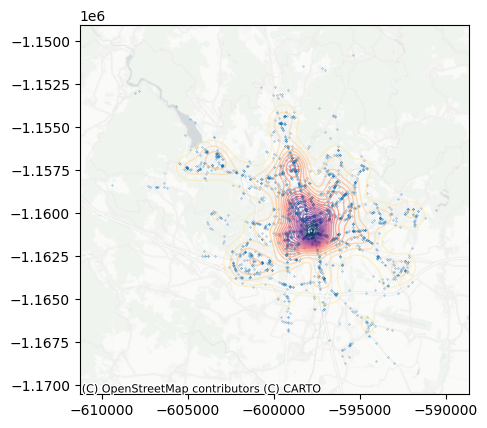

In [ ]:
f, ax = plt.subplots()
brno_df.plot(ax=ax, markersize=0.05)
pointpats.plot_density(brno_df, bandwidth=500, levels = 25, alpha = 0.60, cmap="magma_r", linewidths = 1, ax=ax)
    # bandwidth: how large the levels are
    # Levels: number of density changes
    # alpha: visibility of levels?
contextily.add_basemap(ax=ax, crs=brno_df.crs, source="CartoDB Positron No Labels")

### Centrography:

- Aims to provide a summary of the pattern. 
    - General location of pattern, dispersion, limits, etc

Tendency: reflected by the centre of mass usually as the mean or median of point coordinates. 
    - Mean, median, and weighted mean should be around the same for a balanced dataset

Dispersion: reflected by the ellipse based on standard deviations of both directions x and y
    - Data is well balanced if the ellipse looks more like a circle

In [ ]:
# Mean of the center of the points
mean_center = pointpats.centrography.mean_center(brno_df)
print(mean_center)
# alternative to printing
print(f"The x-coordinate of the mean is: {mean_center.x}")
print(f"The y-coordinate of the mean is: {mean_center.y}")

# Median of the points
med_center = pointpats.centrography.euclidean_median(brno_df)
print(med_center)

# Weighted mean based on some arbitrary value
weighted_mean = pointpats.centrography.weighted_mean_center(brno_df, brno_df["lehce_zran_os"])
print(weighted_mean)
weighted_mean # gives the single point, not with much else to go off of

In [ ]:
# ellipse that is made of standard deviations in each direction
ellipse = pointpats.centrography.ellipse(brno_df)
ellipse

In [ ]:
f, ax = plt.subplots()
brno_df.plot(ax=ax, markersize=0.05)

ax.scatter(*mean_center.xy, color="k", marker="o", label="Mean", alpha=0.8)
ax.scatter(*med_center.xy, color="r", marker="o", label="Median", alpha=0.8)
ax.scatter(*weighted_mean.xy, color = "pink", marker = "o", label = "Weighted mean", alpha = 0.8)

gpd.GeoSeries([ellipse.boundary], crs = brno_df.crs).plot(ax=ax, color = "red", linestyle="--")
ax.legend(loc="upper left")

contextily.add_basemap(ax=ax, crs=brno_df.crs, source="CartoDB Positron No Labels")

plt.xticks(rotation=90)

Centrography is useful for comparing multiple point patterns.

We begin by analyzing the point pattern itself, then plot the mean and ellipse to see it in a more standard visualization

Below, we see the different scatter plots and ellipses for night and day in the dataset. 

In [ ]:
# Events between the day and night
day = brno_df[brno_df["doba"] == "den"]
night = brno_df[brno_df["doba"] == "noc"]

f, axs = plt.subplots(1, 2, sharey=True)
day.plot(color="red", markersize=.05, ax=axs[0])
night.plot(color='blue', markersize=.05, ax=axs[1])
for ax in axs:
    ax.set_axis_off()

In [ ]:
# Ellipses by day and night
mean_center_day = pointpats.centrography.mean_center(day)
mean_center_night = pointpats.centrography.mean_center(night)

ellipse_day = pointpats.centrography.ellipse(
    day
)
ellipse_night = pointpats.centrography.ellipse(
    night
)

f, ax = plt.subplots()
brno_df.plot(ax=ax, markersize=0.05)

ax.scatter(*mean_center_day.xy, color="red", marker="o", label="Mean Center [Day]", alpha=0.8)
gpd.GeoSeries([ellipse_day.boundary], crs=brno_df.crs).plot(
    ax=ax,
    color="red",
    linestyle="--"
)

ax.scatter(*mean_center_night.xy, color="blue", marker="o", label="Mean Center [Night]", alpha=0.8)
gpd.GeoSeries([ellipse_night.boundary], crs=brno_df.crs).plot(
    ax=ax,
    color="blue",
    linestyle="--"
)

ax.legend(loc="upper left")

contextily.add_basemap(
    ax=ax,
    crs=brno_df.crs,
    source="CartoDB Positron No Labels",
)
plt.xticks(rotation=90)

### Randomness and clustering

Point patterns CAN be random, but more often than not, they are non-random. A **quadrat statistic** tries to make sense of what you are looking at. 

Quadrat statistic:

- Examines the evenness of the distribution over cells using a chi-squared statistical test commonly used in contingency tables
- Is a test of randomness, since if it were truly random we would see similar number of points across cells. It is very similar to a scatter plot test

In [ ]:
# Create a quadrat statistic object
qstat = pointpats.QStatistic(brno_df, nx = 6, ny = 6)
# Default number of points on the x and y axis is 3, respectively

# this gives you your observed chi squared statistic
print(f"This is the chi-squared test statistic: {qstat.chi2}")

# this is the chi-squared statistic p-value
print(f"This is the p-value of the chi-squared test: {qstat.chi2_pvalue}")

In the case of this data set, the points are clearly not evenly distributed across the cells, hence the point pattern is unlikely to be random

Here we can create a visual of the points with a lattice structure lain overtop. 

In [ ]:
ax = qstat.plot()
contextily.add_basemap(ax = ax, crs = brno_df.crs, source = "CartoDB Positron No Labels")
plt.xticks(rotation = 90)

**Ripley's functions**: 

- Commonly a better option for the assessment of the randomness of a point pattern
    - Works with the concept of nearest neighbours and aim to capture co-location of points in the pattern
- For example, in the above quadrat statistic, some boxes have 0 simply because the shape of the lattice does not work well with the shape of the point pattern. 
- Ripley's functions are based on the area of the existing point pattern

To define the extent of the point pattern you are observing, you can use geopandas

In [ ]:
# Generate a shapely Polygon using concave hull
concave_hull = brno_df.dissolve().concave_hull(ratio=0.1)

# Plot the concave hull using a geopandas geoseries
ax = brno_df.plot(markersize=0.05)
concave_hull.plot(ax=ax, facecolor="none", edgecolor="k", linestyle="--")
plt.xticks(rotation=90)

*G function*: Ripley's *G* is an iterative algorithm

- Measures how many points have the nearest point within a threshold distance while repeatedly increasing the threshold
- The series of thresholds and counts results in a specific curve that is compare to the curve from a purely random point process (straight line)

In the below code, we can see a plot of ripley's G curve compared to a random point process

In [ ]:
# Using ripley's G function
ripley_g = pointpats.distance_statistics.g_test(brno_df, 
                                                support=200,  # number of bins of distance
                                                keep_simulations=True, # keep simulations to plot
                                                hull = concave_hull.item(),  # limit to the concave_hull item
                                                n_simulations=100)

# Plot the ripley's g test from observed data versus the median simulated data
f, ax = plt.subplots()
ax.plot(ripley_g.support, ripley_g.simulations.T, color="lightgrey")
ax.plot(
    ripley_g.support,
    np.median(ripley_g.simulations, axis=0),
    color="k",
    label="median simulation",
    linestyle="--",
)
ax.plot(ripley_g.support, ripley_g.statistic, label="observed", color="red")
ax.set_xlabel("distance [m]")
ax.set_ylabel(
    "Ratio of nearest neighbor\n"
    "distances shorter than distance"
)
ax.legend()
ax.set_xlim(0, 500)


The plot above shows us the ripley's g test based on the observed data versus a median simulation. 

- The observed data shows that there is a higher ratio of points closer to a single point at a shorter distance, then a slight overlap around 250 meters
    - From there, the observed data ratio dips slightly below the median, but at that distance, the ratio is already rather high
    - The observed data is rather clustered
- The median simulation resembles a sigmoid function for when the point pattern is random

We can also then extract the p-value of the g test, making it obvious that the pattern is not random

In [ ]:
# Generate the p-value of the ripley's g test, value may be different, but all under 0.05
print(f"The p-value of the g test is: {np.mean(ripley_g.pvalue)}")

*F Function*: Ripley's F function

- Similarly iterative like the G function, but instead of point to point, it focuses on distance to points from locations within empty space
- That empty space location is from a generated random point pattern within the same hull

In [ ]:
# Generate the ripley's F test
ripley_f = pointpats.distance_statistics.f_test(
    brno_df,
    support=200,
    keep_simulations=True,
    hull=concave_hull.item(),
    n_simulations=100
)

# generate the plot of the f test against a median simulation
f, ax = plt.subplots()
ax.plot(ripley_f.support, ripley_f.simulations.T, color="lightgrey")
ax.plot(
    ripley_f.support,
    np.median(ripley_f.simulations, axis=0),
    color="k",
    label="median simulation",
    linestyle="--",
)
ax.plot(ripley_f.support, ripley_f.statistic, label="observed", color="red")
ax.set_xlabel("distance")
ax.set_ylabel("ratio of points within a distance threshold")
ax.legend()
ax.set_xlim(0, 2000)

Ripley's f test statistic here is below the simulated, which means that the ratio of points increases slower than a random pattern. 

- This leads us to think that the pattern is clustered rather than random
- The p value also gives us the impression that the point pattern is not random

In [ ]:
print(f"The p-value of the ripley's f test is: {np.mean(ripley_f.pvalue)}")

**Locating clusters**

Using DBSCAN (density-based spatial clustering of applications), we can determine where exactly the points are most dense.

- can specify the minimum amount of points to be considered a cluster

In [ ]:
dbscan_100 = cluster.DBSCAN(eps=100, min_samples=20)
# DBSCAN Fitted to the x and y coordinates of the dataset
dbscan_100.fit(brno_df[["x", "y"]])

In [ ]:
# Cluster labels from the DBSCAN object
dbscan_100.labels_
# -1 is noise while anything else is a cluster label
brno_df['cluster'] = dbscan_100.labels_

# noise from the data set
noise = brno_df[dbscan_100.labels_ == -1]
# actual clusters
clusters = brno_df[dbscan_100.labels_ != -1]

In [ ]:
# Plotting the clusters on top of the noise, without labels
ax = brno_df[brno_df["cluster"] == -1].plot(markersize=0.05)
brno_df[brno_df["cluster"] != -1].plot(ax=ax, markersize= 0.1)
contextily.add_basemap(ax=ax, crs=brno_df.crs, source = "CartoDB Positron No Labels")
plt.xticks(rotation=90)

In [ ]:
# plotting where the clusters are in the data set, and labelling them
ax = brno_df[brno_df["cluster"] == -1].plot(markersize=0.05, color = "grey")
brno_df[brno_df["cluster"] != -1].plot("cluster", categorical = True, ax=ax, markersize= 0.1, legend=True, )
contextily.add_basemap(ax=ax, crs=brno_df.crs, source = "CartoDB Positron No Labels")
plt.xticks(rotation=90)